----------------------------------------------  Run this on google colab -----------------------------------------

# Scorpion Detection using Faster R-CNN (ResNet-50)
**Master's Thesis Project: Comparative Study of Object Detection Architectures**

### Objective
To train a two-stage detector (Faster R-CNN) to identify camouflaged scorpions in residential environments, focusing on maximizing **spatial accuracy** and **Intersection over Union (IoU)**.

### Environment Setup


In this section, we prepare the training environment by mounting Google Drive and importing essential PyTorch and Torchvision libraries.

In [ ]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="10tZbw4ePAZ4ItQ7k8us")
project = rf.workspace("scorpion-qedxm").project("custom-workflow-object-detection-vkkm1")
version = project.version(4)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...


### Data Loading & Pre-processing

The scorpion dataset requires specific handling due to low-salience targets. We implement custom data transformations, including normalization and image resizing, to prepare the raw data for the ResNet-50 backbone.

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target


In [ ]:
# Dataset class
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="/content/Custom-Workflow-Object-Detection-4/train",
    ann_file="/content/Custom-Workflow-Object-Detection-4/train/_annotations.coco.json"
)


val_dataset = get_coco_dataset(
    img_dir="/content/Custom-Workflow-Object-Detection-4/valid",
    ann_file="/content/Custom-Workflow-Object-Detection-4/valid/_annotations.coco.json"
)



# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


### Model Initialization

We utilize a pre-trained Faster R-CNN with a Feature Pyramid Network (FPN). The box predictor head is modified to accommodate our binary classification task (Scorpion vs. Background).

In [ ]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
# Initialize the model
num_classes = 2 # Background + scorpion
model = get_model(num_classes)

In [ ]:
# Move model to GPU if available
device = torch.device('cuda') #if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


In [ ]:
!cat /content/fasterrcnn_utils/engine.py
!cat /content/fasterrcnn_utils/coco_utils.py
!cat /content/fasterrcnn_utils/coco_eval.py
import torchvision
print(torchvision.__version__)
!mkdir -p fasterrcnn_utils
!wget -q https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py -P fasterrcnn_utils
!wget -q https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py -P fasterrcnn_utils
!wget -q https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py -P fasterrcnn_utils
!wget -q https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py -P fasterrcnn_utils

import sys
sys.path.append('/content/fasterrcnn_utils')
!pip install transforms
!pip install sgmllib3k
import transforms as T
from coco_utils import get_coco_api_from_dataset
import torchvision
print(torchvision.__version__)
import transforms
print(transforms.__file__)
from engine import evaluate

import math
import sys
import time

import torch
import torchvision.models.detection.mask_rcnn
import utils
from coco_eval import CocoEvaluator
from coco_utils import get_coco_api_from_dataset


def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq, scaler=None):
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))
    header = f"Epoch: [{epoch}]"

    lr_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)

        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for images, targets in metric_logger.log_every(data_loader, print_freq, header):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items

In [ ]:
from torchvision.ops import box_iou
import numpy as np

def evaluate_model(model, data_loader, device):
    model.eval()
    loss_classifier_total = 0
    loss_box_reg_total = 0
    count = 0

    # For mAP, precision, and recall calculation
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            processed_targets = []
            valid_images = []

            # Process targets the same way as in train_one_epoch
            for i, target in enumerate(targets):
                boxes = []
                labels = []
                for obj in target:
                    bbox = obj["bbox"]
                    x, y, w, h = bbox
                    if w > 0 and h > 0:
                        boxes.append([x, y, x + w, y + h])
                        labels.append(obj["category_id"])

                if boxes:
                    processed_target = {
                        "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                        "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                    }
                    processed_targets.append(processed_target)
                    valid_images.append(images[i])

            if not processed_targets:
                continue

            images = valid_images

            # Compute losses
            model.train()
            loss_dict = model(images, processed_targets)
            model.eval()  # Switch back to eval mode
            loss_classifier_total += loss_dict["loss_classifier"].item()
            loss_box_reg_total += loss_dict["loss_box_reg"].item()
            count += 1

            # Get predictions for mAP calculation
            model_predictions = model(images)

            # Store predictions and targets for mAP calculation
            for i, prediction in enumerate(model_predictions):
                all_predictions.append(prediction)
                all_targets.append(processed_targets[i])

    # Calculate mAP
    mAP50, mAP5095 = calculate_map(all_predictions, all_targets)

    # Calculate precision and recall
    precision, recall = calculate_precision_recall(all_predictions, all_targets)

    return loss_classifier_total / count, loss_box_reg_total / count, mAP50, mAP5095, precision, recall

def calculate_precision_recall(predictions, targets):
    """
    Calculate precision and recall based on predictions and targets.
    """
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    for pred, target in zip(predictions, targets):
        pred_boxes = pred["boxes"]
        pred_labels = pred["labels"]
        target_boxes = target["boxes"]
        target_labels = target["labels"]

        for pred_box, pred_label in zip(pred_boxes, pred_labels):
            ious = box_iou(pred_box.unsqueeze(0), target_boxes)
            max_iou, max_idx = ious.max(0)
            if max_iou >= 0.5 and pred_label == target_labels[max_idx]:
                true_positives += 1
            else:
                false_positives += 1

        for target_box, target_label in zip(target_boxes, target_labels):
            ious = box_iou(target_box.unsqueeze(0), pred_boxes)
            if not (ious >= 0.5).any():
                false_negatives += 1

    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)

    return precision, recall
def calculate_map(predictions, targets, iou_thresholds=None):
    """
    Calculate mAP at different IoU thresholds
    """
    if iou_thresholds is None:
        iou_thresholds = [0.5]  # For mAP@0.5

    # For mAP@0.5:0.95
    iou_range = torch.linspace(0.5, 0.95, 10)

    # Calculate mAP@0.5
    mAP50 = calculate_average_precision(predictions, targets, iou_threshold=0.5)

    # Calculate mAP@0.5:0.95
    ap_list = []
    for iou_threshold in iou_range:
        ap = calculate_average_precision(predictions, targets, iou_threshold=iou_threshold.item())
        ap_list.append(ap)
    mAP5095 = sum(ap_list) / len(ap_list) if ap_list else 0

    return mAP50, mAP5095

def calculate_average_precision(predictions, targets, iou_threshold=0.5):
    """
    Calculate average precision at a specific IoU threshold
    """
    # Implement AP calculation based on precision-recall curve
    if not predictions or not targets:
        return 0.0

    # Get all unique classes
    all_classes = set()
    for target in targets:
        all_classes.update(target["labels"].cpu().numpy())

    average_precisions = []

    # Calculate AP for each class
    for cls in all_classes:
        true_positives = []
        false_positives = []
        scores_list = []

        # Get all predictions and ground truths for this class
        for i, (pred, target) in enumerate(zip(predictions, targets)):
            # Filter predictions by class
            pred_indices = (pred["labels"] == cls).nonzero(as_tuple=True)[0]
            pred_boxes = pred["boxes"][pred_indices]
            pred_scores = pred["scores"][pred_indices]

            # Filter targets by class
            target_indices = (target["labels"] == cls).nonzero(as_tuple=True)[0]
            target_boxes = target["boxes"][target_indices]

            # Sort predictions by score
            sorted_indices = torch.argsort(pred_scores, descending=True)
            pred_boxes = pred_boxes[sorted_indices]
            pred_scores = pred_scores[sorted_indices]

            # Initialize detection status for target boxes
            detected = [False] * len(target_boxes)

            # Check each prediction
            for box, score in zip(pred_boxes, pred_scores):
                scores_list.append(score.item())

                if len(target_boxes) == 0:
                    false_positives.append(1)
                    true_positives.append(0)
                    continue

                # Calculate IoU with all target boxes
                ious = box_iou(box.unsqueeze(0), target_boxes)[0]

                # Get the best IoU and its index
                best_iou, best_idx = torch.max(ious, dim=0)

                if best_iou >= iou_threshold and not detected[best_idx]:
                    true_positives.append(1)
                    false_positives.append(0)
                    detected[best_idx] = True
                else:
                    true_positives.append(0)
                    false_positives.append(1)

        # Continue to next class if no predictions
        if not scores_list:
            continue

        # Convert to numpy arrays for easier manipulation
        true_positives = np.array(true_positives)
        false_positives = np.array(false_positives)

        # Calculate cumulative sums
        cum_true_positives = np.cumsum(true_positives)
        cum_false_positives = np.cumsum(false_positives)

        # Count total number of ground truth objects
        total_gt = sum(len((target["labels"] == cls).nonzero(as_tuple=True)[0]) for target in targets)

        # Calculate precision and recall
        precision = cum_true_positives / (cum_true_positives + cum_false_positives + 1e-10)
        recall = cum_true_positives / (total_gt + 1e-10)

        # Compute AP using the 11-point interpolation
        ap = 0
        for r in np.linspace(0, 1, 11):
            p_interp = 0
            for i in range(len(precision)):
                if recall[i] >= r:
                    p_interp = max(p_interp, precision[i])
            ap += p_interp / 11

        average_precisions.append(ap)

    # Return mean AP across all classes
    return sum(average_precisions) / len(average_precisions) if average_precisions else 0.0

def box_iou(boxes1, boxes2):
    """
    Calculate IoU between two sets of boxes
    """
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])  # (N, M, 2)
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])  # (N, M, 2)

    wh = (rb - lt).clamp(min=0)  # (N, M, 2)
    intersection = wh[:, :, 0] * wh[:, :, 1]  # (N, M)

    union = area1[:, None] + area2 - intersection

    iou = intersection / (union + 1e-10)
    return iou

In [ ]:
import matplotlib.pyplot as plt

def plot_training_validation_metrics(
    train_cls_losses,
    train_box_losses,
    val_cls_losses,
    val_box_losses,
    map50_scores,
    map5095_scores,
    precision_scores,
    recall_scores
):
    """
    Plot training and validation metrics for Faster R-CNN.
    """
    epochs = range(1, len(train_cls_losses) + 1)

    plt.figure(figsize=(20, 12))

    # Classification Loss
    plt.subplot(2, 3, 1)
    plt.plot(epochs, train_cls_losses, 'b-', label='Train Classification Loss')
    plt.plot(epochs, val_cls_losses, 'r-', label='Val Classification Loss')
    plt.title('Classification Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Box Regression Loss
    plt.subplot(2, 3, 2)
    plt.plot(epochs, train_box_losses, 'b-', label='Train Box Loss')
    plt.plot(epochs, val_box_losses, 'r-', label='Val Box Loss')
    plt.title('Box Regression Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Total Loss (Classification + Box)
    plt.subplot(2, 3, 3)
    train_total = [cls + box for cls, box in zip(train_cls_losses, train_box_losses)]
    val_total = [cls + box for cls, box in zip(val_cls_losses, val_box_losses)]
    plt.plot(epochs, train_total, 'b-', label='Train Total Loss')
    plt.plot(epochs, val_total, 'r-', label='Val Total Loss')
    plt.title('Total Loss (Classification + Box)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # mAP Scores
    plt.subplot(2, 3, 4)
    plt.plot(epochs, map50_scores, 'g-', label='mAP@0.5')
    plt.plot(epochs, map5095_scores, 'm-', label='mAP@0.5:0.95')
    plt.title('mAP Scores')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # Precision
    plt.subplot(2, 3, 5)
    plt.plot(epochs, precision_scores, 'c-', label='Precision')
    plt.title('Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # Recall
    plt.subplot(2, 3, 6)
    plt.plot(epochs, recall_scores, 'y-', label='Recall')
    plt.title('Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_validation_metrics.png')
    plt.show()

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    loss_classifier_total = 0
    loss_box_reg_total = 0
    count = 0
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        processed_targets = []
        valid_images = []
        for i, target in enumerate(targets):
            boxes = []
            labels = []
            for obj in target:
                bbox = obj["bbox"]
                x, y, w, h = bbox
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])
                    labels.append(obj["category_id"])
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])
        if not processed_targets:
            continue
        images = valid_images
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        loss_classifier_total += loss_dict["loss_classifier"].item()
        loss_box_reg_total += loss_dict["loss_box_reg"].item()
        count += 1
    return loss_classifier_total / count, loss_box_reg_total / count

In [ ]:
def train_model(model, optimizer, lr_scheduler, train_loader, val_loader, device, num_epochs):
    history = {
        "train_cls_losses": [],
        "train_box_losses": [],
        "val_cls_losses": [],
        "val_box_losses": [],
        "map50_scores": [],
        "map5095_scores": [],
        "precision_scores": [],
        "recall_scores": [],
    }

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train one epoch
        train_cls_loss, train_box_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
        print(f"  Training: cls_loss={train_cls_loss:.4f}, box_loss={train_box_loss:.4f}")

        # Evaluate
        val_cls_loss, val_box_loss, map50, map5095, precision, recall = evaluate_model(model, val_loader, device)
        print(f"  Validation: cls_loss={val_cls_loss:.4f}, box_loss={val_box_loss:.4f}, mAP50={map50:.4f}, mAP50-95={map5095:.4f}, precision={precision:.4f}, recall={recall:.4f}")

        # Store metrics
        history["train_cls_losses"].append(train_cls_loss)
        history["train_box_losses"].append(train_box_loss)
        history["val_cls_losses"].append(val_cls_loss)
        history["val_box_losses"].append(val_box_loss)
        history["map50_scores"].append(map50)
        history["map5095_scores"].append(map5095)
        history["precision_scores"].append(precision)
        history["recall_scores"].append(recall)

        # Step LR scheduler if used
        if lr_scheduler is not None:
            lr_scheduler.step()
    # Plot training and validation metrics
    plot_training_validation_metrics(
        history["train_cls_losses"],
        history["train_box_losses"],
        history["val_cls_losses"],
        history["val_box_losses"],
        history["map50_scores"],
        history["map5095_scores"],
        history["precision_scores"],
        history["recall_scores"]
    )
    return model, history


In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torch

# Define the model creation function
def create_model(num_classes):
    # Load a pre-trained model for the backbone
    backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

    # Remove the avg pool and FC layers
    modules = list(backbone.children())[:-2]
    backbone = torch.nn.Sequential(*modules)

    # Set the out_channels
    backbone.out_channels = 2048  # Required for FasterRCNN

    # Define anchor generator
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # Define ROI pooling
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=["0"],
        output_size=7,
        sampling_ratio=2
    )

    # Create Faster R-CNN model
    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    return model


Epoch 1/20
  Training: cls_loss=0.1193, box_loss=0.1015
  Validation: cls_loss=0.0504, box_loss=0.0643, mAP50=0.2015, mAP50-95=0.1172, precision=0.2744, recall=1.0000
Epoch 2/20
  Training: cls_loss=0.0416, box_loss=0.0539
  Validation: cls_loss=0.0221, box_loss=0.0258, mAP50=0.5884, mAP50-95=0.4975, precision=0.5510, recall=1.0000
Epoch 3/20
  Training: cls_loss=0.0262, box_loss=0.0333
  Validation: cls_loss=0.0122, box_loss=0.0110, mAP50=0.7946, mAP50-95=0.7457, precision=0.8182, recall=1.0000
Epoch 4/20
  Training: cls_loss=0.0223, box_loss=0.0260
  Validation: cls_loss=0.0137, box_loss=0.0082, mAP50=0.7691, mAP50-95=0.7348, precision=0.7788, recall=1.0000
Epoch 5/20
  Training: cls_loss=0.0218, box_loss=0.0258
  Validation: cls_loss=0.0141, box_loss=0.0080, mAP50=0.7935, mAP50-95=0.7643, precision=0.8367, recall=1.0000
Epoch 6/20
  Training: cls_loss=0.0211, box_loss=0.0246
  Validation: cls_loss=0.0133, box_loss=0.0087, mAP50=0.6937, mAP50-95=0.6793, precision=0.6750, recall=1.000

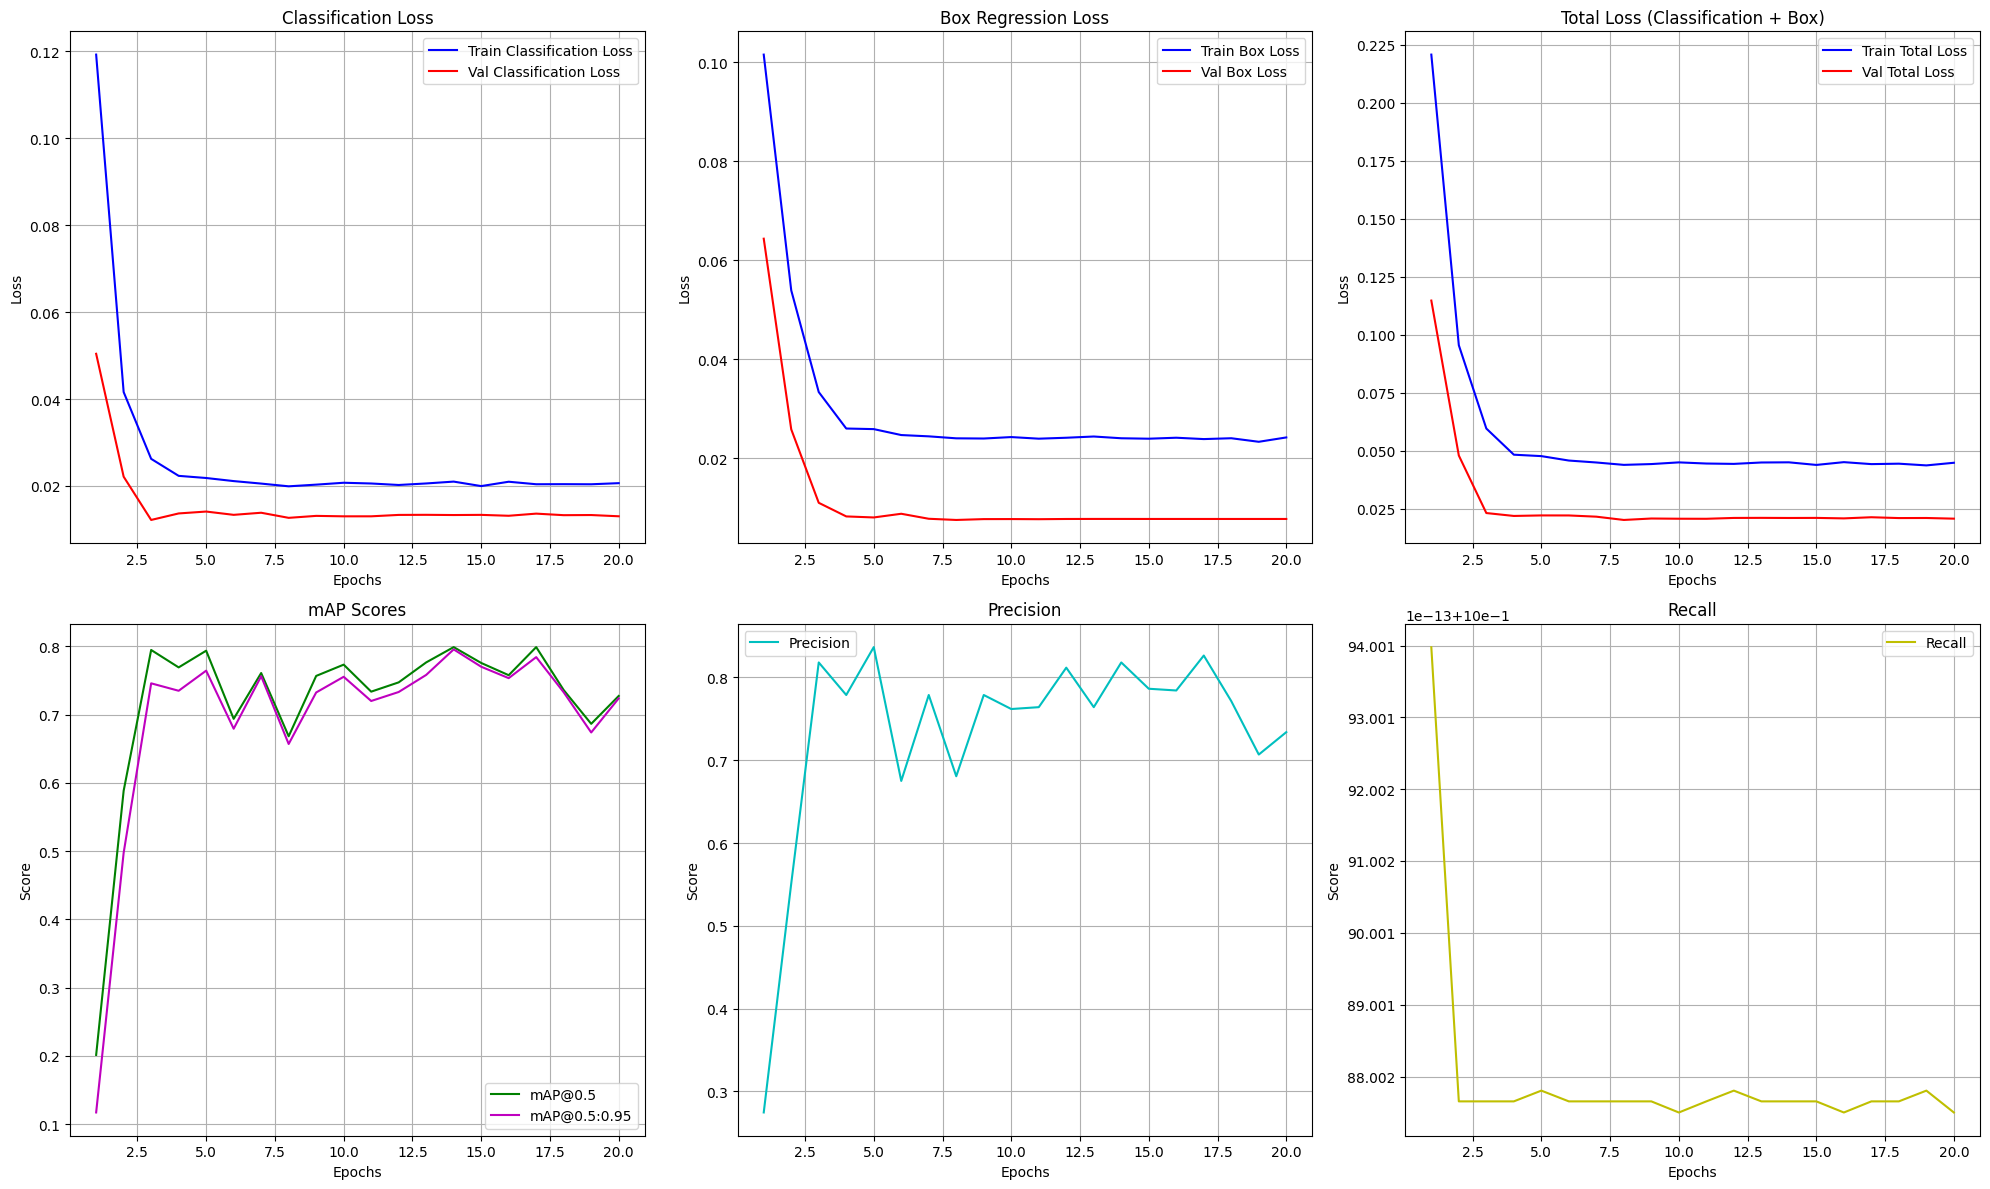

In [ ]:

# Set up model, optimizer, etc.
device = torch.device('cuda') #if torch.cuda.is_available() else torch.device('cpu')
model = create_model(num_classes).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Train the model
model, metrics = train_model(model, optimizer, lr_scheduler, train_loader, val_loader, device, num_epochs=20)


In [ ]:
# save model and graphs
model_save_path = "/content/drive/MyDrive/Scorpion_traning/fasterrcnn_resnet50_final.pth"
plot_save_path = "/content/drive/MyDrive/Scorpion_traning/training_validation_metrics.png"

# save the model
torch.save(model.state_dict(), model_save_path)
print(f"Model saved  : {model_save_path}")

# Sauvegarder the graphs
import shutil
shutil.copy("training_validation_metrics.png", plot_save_path)
print(f"plot saved  : {plot_save_path}")

In [ ]:
#torch.save(model, "/content/drive/MyDrive/MyPlots/fasterrcnn_resnet50_epoch_20_final.pth")